In [24]:
from langgraph.graph import StateGraph, START, END

from pydantic import BaseModel, Field
from typing import TypedDict, Any

In [25]:
# class State(BaseModel):
#     num1: int = Field(..., description="The first number to add/substract/multiply/divide")
#     num2: int = Field(..., description="The second number to add/substract/multiply/divide")
#     symbol: str = Field(..., description="The operation symbol: +, -, *, /")
#     route: str = Field(..., description="The route for the calculation")
#     result: int = Field(..., description="The result of the calculation")

class State(TypedDict):
    num1: int
    num2: int
    symbol: str
    route: str
    result: int

In [45]:
def choose_route(state: State):
    if state['symbol'] in ['+']:
        state['route'] = 'add'
    elif state['symbol'] in ['-']:
        state['route'] = 'subtract'
    elif state['symbol'] in ['*']:
        state['route'] = 'multiply'
    elif state['symbol'] in ['/']:
        state['route'] = 'divide'
    else:
        state['route'] = 'unknown_operation'

    return state

In [46]:
def next_node(state: State):
    return state['route']

In [28]:
def calculate(state: State):
    if state['route'] == 'add':
        state['result'] = state['num1'] + state['num2']
    elif state['route'] == 'subtract':
        state['result'] = state['num1'] - state['num2']
    elif state['route'] == 'multiply':
        state['result'] = state['num1'] * state['num2']
    elif state['route'] == 'divide':
        if state['num2'] != 0:
            state['result'] = state['num1'] / state['num2']
        else:
            raise ValueError("Cannot divide by zero.")
    return state

In [29]:
graph = StateGraph(State)

graph.add_node("choose_route", choose_route)
graph.add_node("calculate", calculate)


graph.add_edge(START, "choose_route")
graph.add_conditional_edges("choose_route", next_node, {
    "add": "calculate",
    "subtract": "calculate",
    "multiply": "calculate",
    "divide": "calculate"
})

graph.add_edge("calculate", END)

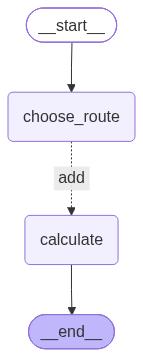

In [30]:
workflow_graph = graph.compile()

workflow_graph

In [32]:
result = workflow_graph.invoke({"num1": 10, "num2": 5, "symbol": "-"})

print(result)

{'num1': 10, 'num2': 5, 'symbol': '-', 'route': 'subtract', 'result': 5}


# now i am creating multiple nodes for each operation and connecting them to the calculate node.

In [53]:
def add(state: State):
    state['result'] = state['num1'] + state['num2']
    return state

def subtract(state: State):
    state['result'] = state['num1'] - state['num2']
    return state

def multiply(state: State):
    state['result'] = state['num1'] * state['num2']
    return state

def divide(state: State):
    if state['num2'] != 0:
        state['result'] = state['num1'] / state['num2']
    else:
        raise ValueError("Cannot divide by zero.")
    return state

def unknown_operation(state: State):
    # raise ValueError(f"Unknown operation: {state['symbol']}")
    state['result'] = f"Unknown operation: {state['symbol']}"
    return state

In [54]:
calculator_graph = StateGraph(State)

calculator_graph.add_node("add", add)
calculator_graph.add_node("subtract", subtract)
calculator_graph.add_node("multiply", multiply)
calculator_graph.add_node("divide", divide)
calculator_graph.add_node("unknown_operation", unknown_operation)
calculator_graph.add_node("choose_route", choose_route)

calculator_graph.add_edge(START, "choose_route")
calculator_graph.add_conditional_edges("choose_route", next_node, {
    "add": "add",
    "subtract": "subtract",
    "multiply": "multiply",
    "divide": "divide",
    "unknown_operation": "unknown_operation"
})
calculator_graph.add_edge("add", END)
calculator_graph.add_edge("subtract", END)
calculator_graph.add_edge("multiply", END)
calculator_graph.add_edge("divide", END)
calculator_graph.add_edge("unknown_operation", END)



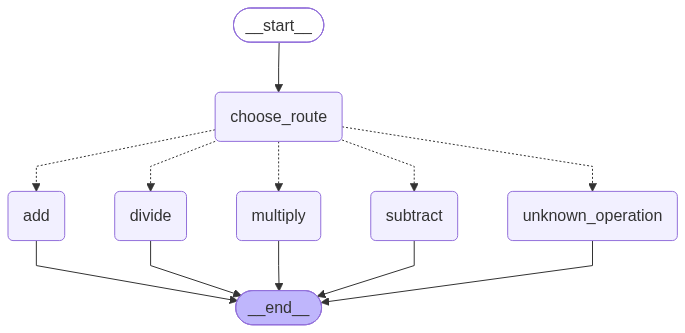

In [55]:
workflow = calculator_graph.compile()

workflow

In [56]:
result = workflow.invoke({"num1": 10, "num2": 5, "symbol": "09"})

print(result)

{'num1': 10, 'num2': 5, 'symbol': '09', 'route': 'unknown_operation', 'result': 'Unknown operation: 09'}
